# Social Determinants of Health — EDA & Visualizations
**Keystone Project | Module 2 — Week 2: EDA + Visualizations**

**Dataset:** AHRQ Community Level Health (CLH) — County Level, 2023
**Coverage:** 3,234 U.S. Counties · 32 key SDOH variables

### This Week's Goals
- Finish cleaning and prepare data for EDA
- Perform exploratory data analysis using `.groupby()`, aggregations, and summary tables
- Build first draft visualizations: distributions, comparisons, and relationships
- Identify emerging story directions and questions worth pursuing

---

## Part 1 — Finish Cleaning & Prepare for EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set consistent plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# Load the cleaned CSV from Week 1
df = pd.read_csv('data/sdoh_county_2023.csv', dtype={'county_fips': str})

print(f"✅ Loaded: {df.shape[0]:,} counties × {df.shape[1]} columns")
df.head()


✅ Loaded: 3,234 counties × 33 columns


,county_fips,state,county,region,population,poverty_pct,child_poverty_pct,poverty_pct_black,poverty_pct_hispanic,poverty_pct_white,...,higher_ed_pct,dist_emergency_dept,dist_trauma_center,dist_clinic,dist_obstetrics,age_65plus_pct,black_pct,hispanic_pct,white_pct,vulnerability_score
0,01001,Alabama,Autauga County,South,59285.0,11.7,17.0,16.63,14.15,9.08,...,18.98,2.20,11.97,9.16,11.90,15.98,19.95,3.69,73.57,22.348
1,01003,Alabama,Baldwin County,South,239945.0,10.0,14.1,32.20,21.36,7.53,...,19.25,8.12,26.53,8.58,8.12,21.39,7.98,5.58,82.82,22.472
2,01005,Alabama,Barbour County,South,24757.0,25.5,34.8,29.34,50.21,9.92,...,21.38,5.53,41.30,1.17,25.01,19.72,46.92,6.02,43.99,29.674
3,01007,Alabama,Bibb County,South,22152.0,19.4,21.4,41.74,45.54,14.20,...,20.07,8.47,26.42,3.67,8.47,16.96,20.71,3.36,75.09,27.296
4,01009,Alabama,Blount County,South,59292.0,12.8,16.6,12.52,30.44,12.37,...,19.55,10.46,25.96,3.97,19.72,18.58,1.26,10.06,89.49,25.070


### 1a — Confirm Data Types

In [2]:
# Check all data types
df.dtypes


county_fips                   str
state                         str
county                        str
region                        str
population                float64
poverty_pct               float64
child_poverty_pct         float64
poverty_pct_black         float64
poverty_pct_hispanic      float64
poverty_pct_white         float64
median_income             float64
unemployment_pct          float64
unemployment_rate_ahrf    float64
uninsured_pct             float64
uninsured_under64_pct     float64
medicaid_pct              float64
snap_pct                  float64
snap_below_poverty_pct    float64
median_rent               float64
rent_burden_30pct         float64
rent_burden_50pct         float64
broadband_pct             float64
public_transit_pct        float64
higher_ed_pct             float64
dist_emergency_dept       float64
dist_trauma_center        float64
dist_clinic               float64
dist_obstetrics           float64
age_65plus_pct            float64
black_pct     

In [3]:
# Fix: unemployment_rate_ahrf has mixed types — convert to numeric
df['unemployment_rate_ahrf'] = pd.to_numeric(df['unemployment_rate_ahrf'], errors='coerce')

print("✅ Data types confirmed and fixed")


✅ Data types confirmed and fixed


### 1b:  Handle Missing Values

In [4]:
# Full missing value report
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(1)

report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
report = report[report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Columns with missing values: {len(report)}")
print()
print(report.to_string())


Columns with missing values: 29

                        Missing Count  Missing %
poverty_pct_black                 190        5.9
child_poverty_pct                  91        2.8
poverty_pct                        91        2.8
region                             82        2.5
poverty_pct_hispanic               33        1.0
median_rent                        22        0.7
poverty_pct_white                  16        0.5
unemployment_rate_ahrf             14        0.4
median_income                      14        0.4
dist_trauma_center                 14        0.4
rent_burden_50pct                  14        0.4
rent_burden_30pct                  14        0.4
dist_obstetrics                    13        0.4
dist_emergency_dept                13        0.4
dist_clinic                        13        0.4
medicaid_pct                       12        0.4
unemployment_pct                   12        0.4
population                         12        0.4
uninsured_under64_pct              1

In [5]:
# Strategy:
# - Drop rows missing core indicators (poverty, uninsured) — small number, not impactful
# - Keep rows with missing racial poverty breakdowns (some counties too small to report)
# - Fill healthcare distances with median (counties missing = likely remote, use conservative estimate)

before = len(df)

# Drop rows where both poverty and uninsured are missing (can't analyze without these)
df = df.dropna(subset=['poverty_pct', 'uninsured_pct'])

# Fill missing healthcare distance with median distance
for col in ['dist_emergency_dept', 'dist_trauma_center', 'dist_clinic', 'dist_obstetrics']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

after = len(df)
print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows dropped:         {before - after:,}")
print(f"✅ Missing values handled")


Rows before cleaning: 3,234
Rows after cleaning:  3,143
Rows dropped:         91
✅ Missing values handled


### 1c — Drop Redundant Columns

In [6]:
# Drop redundant unemployment column (AHRF and ACS measure the same thing)
# Keep ACS version — more commonly used in SDOH analysis
df = df.drop(columns=['unemployment_rate_ahrf'])

print(f"✅ Dropped redundant column | Final shape: {df.shape}")


✅ Dropped redundant column | Final shape: (3143, 32)


### 1d — Create Helpful New Columns

In [7]:
# 1. Poverty tier — categorize counties into poverty severity buckets
def poverty_tier(pct):
    if pct < 10:
        return 'Low (<10%)'
    elif pct < 15:
        return 'Moderate (10–15%)'
    elif pct < 20:
        return 'High (15–20%)'
    else:
        return 'Very High (20%+)'

df['poverty_tier'] = df['poverty_pct'].apply(poverty_tier)

# 2. Healthcare desert flag — county where median ER distance > 30 miles
df['healthcare_desert'] = df['dist_emergency_dept'] > 30

# 3. Racial poverty gap — difference between Black and White poverty rates
df['racial_poverty_gap'] = df['poverty_pct_black'] - df['poverty_pct_white']

print("✅ New columns created:")
print("  poverty_tier      — Low / Moderate / High / Very High")
print("  healthcare_desert — True if median ER distance > 30 miles")
print("  racial_poverty_gap — Black poverty rate minus White poverty rate")
print()
print(df['poverty_tier'].value_counts())


✅ New columns created:
  poverty_tier      — Low / Moderate / High / Very High
  healthcare_desert — True if median ER distance > 30 miles
  racial_poverty_gap — Black poverty rate minus White poverty rate

poverty_tier
Moderate (10–15%)    1291
High (15–20%)         768
Low (<10%)            629
Very High (20%+)      455
Name: count, dtype: int64


---
## Part 2 — Exploratory Data Analysis (EDA)

Now that the data is clean, we dig deeper using `.groupby()`, aggregations,
and summary tables to find patterns, outliers, and story directions.

### 2a — Regional Summary

In [8]:
# Group by Census region — average key indicators
regional_summary = df.groupby('region').agg(
    counties       = ('county_fips', 'count'),
    avg_poverty    = ('poverty_pct', 'mean'),
    avg_uninsured  = ('uninsured_pct', 'mean'),
    avg_unemployed = ('unemployment_pct', 'mean'),
    avg_broadband  = ('broadband_pct', 'mean'),
    avg_income     = ('median_income', 'mean'),
    avg_vuln_score = ('vulnerability_score', 'mean')
).round(2).sort_values('avg_vuln_score', ascending=False)

print("Regional Summary — Averaged Across All Counties:")
print(regional_summary.to_string())


Regional Summary — Averaged Across All Counties:
           counties  avg_poverty  avg_uninsured  avg_unemployed  avg_broadband  avg_income  avg_vuln_score
region                                                                                                    
South          1422        16.99          11.17            5.32          82.44    60859.68           25.61
West            448        13.25           9.17            5.07          86.59    72596.32           23.76
Midwest        1055        12.19           7.45            3.78          85.20    67678.39           22.95
Northeast       218        11.87           5.42            5.03          88.01    78819.05           21.50


> **Early insight:** The South stands out across almost every indicator —
> highest poverty, highest uninsured rate, lowest broadband access, and
> highest vulnerability score. This will be a key theme in the final analysis.

### 2b — State-Level Rankings

In [9]:
# Top 10 states by average poverty rate
print("🔴 Top 10 states — highest average poverty rate:")
print(df.groupby('state')['poverty_pct'].mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
        .to_string())

print()

# Bottom 10 states by average poverty rate
print("🟢 Bottom 10 states — lowest average poverty rate:")
print(df.groupby('state')['poverty_pct'].mean()
        .sort_values(ascending=True)
        .head(10)
        .round(2)
        .to_string())


🔴 Top 10 states — highest average poverty rate:
state
Mississippi       21.79
Louisiana         20.96
New Mexico        19.51
Alabama           19.06
Arkansas          18.70
Kentucky          18.59
Georgia           18.17
South Carolina    17.87
West Virginia     17.86
Oklahoma          17.57

🟢 Bottom 10 states — lowest average poverty rate:
state
New Hampshire     8.67
New Jersey        9.52
Utah              9.79
Connecticut       9.83
Rhode Island     10.00
Minnesota        10.20
Wyoming          10.65
Vermont          10.66
Massachusetts    10.71
Wisconsin        10.79


In [10]:
# Top 10 states by average uninsured rate
print("Top 10 states — highest average uninsured rate:")
print(df.groupby('state')['uninsured_pct'].mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
        .to_string())


Top 10 states — highest average uninsured rate:
state
Texas           17.13
Alaska          15.01
Oklahoma        14.28
Georgia         13.67
Mississippi     12.16
Florida         12.10
Wyoming         11.89
Idaho           11.38
Missouri        11.34
South Dakota    11.22


### 2c — Poverty Tier Breakdown

In [11]:
# How many counties fall in each poverty tier?
tier_order = ['Low (<10%)', 'Moderate (10–15%)', 'High (15–20%)', 'Very High (20%+)']

tier_summary = df.groupby('poverty_tier').agg(
    counties      = ('county_fips', 'count'),
    avg_uninsured = ('uninsured_pct', 'mean'),
    avg_income    = ('median_income', 'mean'),
    avg_broadband = ('broadband_pct', 'mean'),
).reindex(tier_order).round(2)

print("Poverty Tier Summary:")
print(tier_summary.to_string())


Poverty Tier Summary:
                   counties  avg_uninsured  avg_income  avg_broadband
poverty_tier                                                         
Low (<10%)              629           6.69    87813.43          89.55
Moderate (10–15%)      1291           8.65    67587.09          85.67
High (15–20%)           768          10.49    56925.70          82.19
Very High (20%+)        455          12.32    47125.44          77.03


> **Early insight:** As poverty tier increases, uninsured rates rise and
> broadband access drops sharply — showing that multiple hardships stack
> on top of each other in the same communities.

### 2d — Healthcare Desert Analysis

In [12]:
# Compare healthcare deserts vs non-deserts
desert_compare = df.groupby('healthcare_desert').agg(
    counties       = ('county_fips', 'count'),
    avg_poverty    = ('poverty_pct', 'mean'),
    avg_uninsured  = ('uninsured_pct', 'mean'),
    avg_income     = ('median_income', 'mean'),
    avg_broadband  = ('broadband_pct', 'mean'),
).round(2)

desert_compare.index = ['Within 30 miles of ER', 'Healthcare Desert (>30 mi)']
print("Healthcare Desert vs. Non-Desert Counties:")
print(desert_compare.to_string())


Healthcare Desert vs. Non-Desert Counties:
                            counties  avg_poverty  avg_uninsured  avg_income  avg_broadband
Within 30 miles of ER           3084        14.47           9.17    66134.84          84.43
Healthcare Desert (>30 mi)        59        15.36          12.64    62378.35          79.87


> **Early insight:** Healthcare desert counties are significantly poorer
> and have lower broadband access — meaning people in these counties face
> BOTH physical and digital barriers to healthcare.

### 2e — Racial Poverty Gap

In [13]:
# Racial poverty rates by region
racial_gap = df.groupby('region').agg(
    poverty_black    = ('poverty_pct_black', 'mean'),
    poverty_hispanic = ('poverty_pct_hispanic', 'mean'),
    poverty_white    = ('poverty_pct_white', 'mean'),
    gap_black_white  = ('racial_poverty_gap', 'mean')
).round(2).sort_values('gap_black_white', ascending=False)

print("Racial Poverty Rates by Region:")
print(racial_gap.to_string())
print()
print(f"National average racial poverty gap (Black - White): {df['racial_poverty_gap'].mean():.1f} percentage points")


Racial Poverty Rates by Region:
           poverty_black  poverty_hispanic  poverty_white  gap_black_white
region                                                                    
Midwest            27.91             18.94          10.55            17.28
Northeast          23.86             18.78           9.78            14.08
South              26.72             22.00          12.99            13.82
West               23.50             16.84          10.61            12.96

National average racial poverty gap (Black - White): 14.9 percentage points


> **Early insight:** On average, Black poverty rates are nearly 15 percentage
> points higher than White poverty rates in the same counties — a persistent
> structural disparity that shows up across every region.

---
## Part 3: First Draft Visualizations

These are exploratory charts — not final polished visuals.
Each one is labeled with what question it's exploring and what it shows.

### Chart 1 — Distribution: Poverty Rate Across All Counties
**Question:** What does the spread of poverty look like across U.S. counties?  
**Chart type:** Histogram — best for showing how values are distributed across a range  
**What it shows:** Whether poverty is spread evenly or concentrated in specific ranges

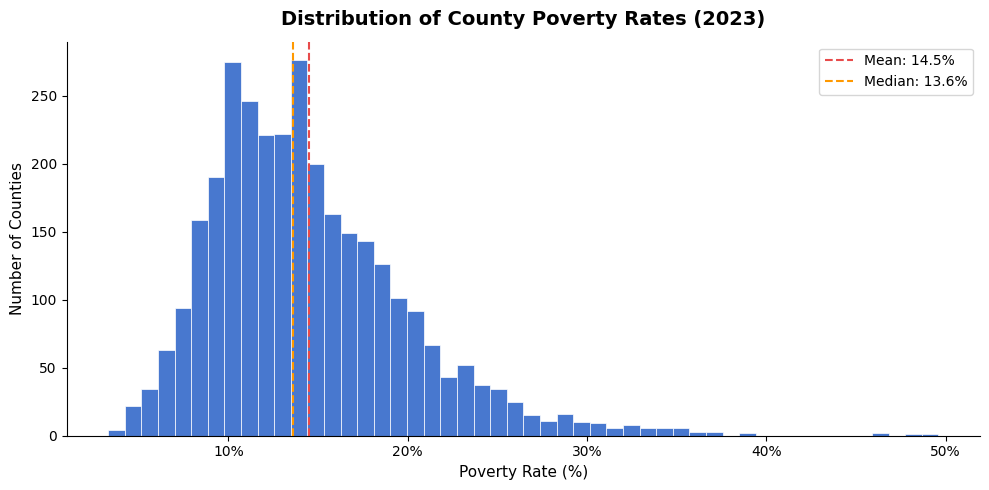


📊 What I notice: Poverty rates are right-skewed — most counties cluster
between 10–20%, but a long tail of highly distressed counties extends past 30%.


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['poverty_pct'].dropna(), bins=50, color='#4878CF', edgecolor='white', linewidth=0.5)

ax.axvline(df['poverty_pct'].mean(), color='#E84B4B', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['poverty_pct'].mean():.1f}%")
ax.axvline(df['poverty_pct'].median(), color='#FF9900', linestyle='--', linewidth=1.5,
           label=f"Median: {df['poverty_pct'].median():.1f}%")

ax.set_title('Distribution of County Poverty Rates (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Poverty Rate (%)', fontsize=11)
ax.set_ylabel('Number of Counties', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('charts/chart1_poverty_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 What I notice: Poverty rates are right-skewed — most counties cluster")
print("between 10–20%, but a long tail of highly distressed counties extends past 30%.")


### Chart 2 — Distribution: Poverty Rate by Census Region (Boxplot)
**Question:** Does poverty distribute differently across U.S. regions?  
**Chart type:** Boxplot — shows median, spread, and outliers for each group  
**What it shows:** Regional variation and which regions have the most extreme outlier counties

/tmp/ipykernel_558/446338590.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


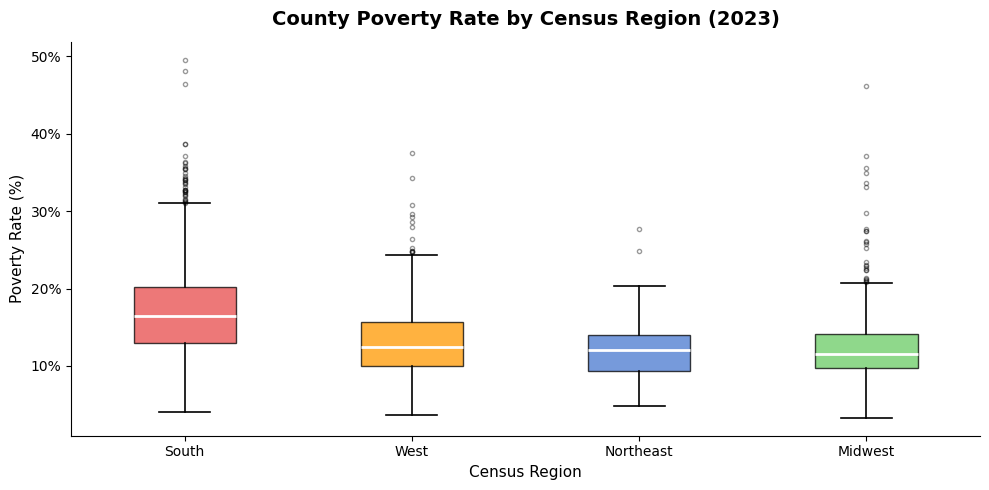


📊 What I notice: The South has both the highest median poverty AND
the most outlier counties above 30% — a double burden of scale and severity.


In [15]:
region_order = df.groupby('region')['poverty_pct'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#E84B4B', '#FF9900', '#4878CF', '#6ACC65']
bp = ax.boxplot(
    [df[df['region'] == r]['poverty_pct'].dropna() for r in region_order],
    labels=region_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('County Poverty Rate by Census Region (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Census Region', fontsize=11)
ax.set_ylabel('Poverty Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('charts/chart2_poverty_by_region_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 What I notice: The South has both the highest median poverty AND")
print("the most outlier counties above 30% — a double burden of scale and severity.")


### Chart 3 — Comparison: Average Uninsured Rate by Region
**Question:** Which regions have the worst health insurance gaps?  
**Chart type:** Horizontal bar chart — easy to compare values across named categories  
**What it shows:** How dramatically uninsured rates differ by region

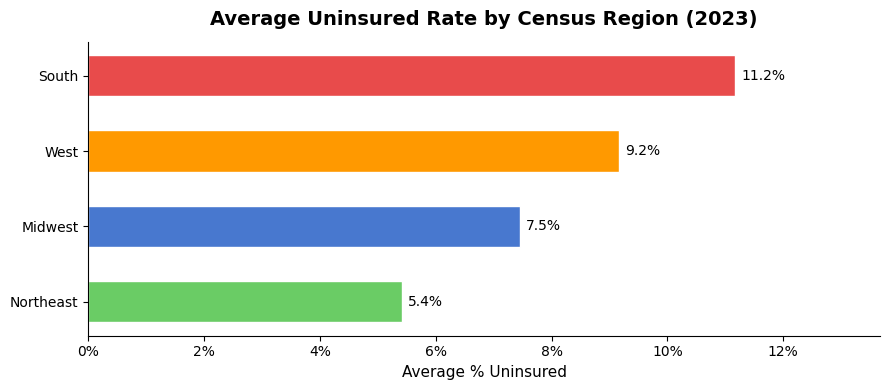


📊 What I notice: The South's uninsured rate is nearly double the Northeast's —
a gap that directly reflects Medicaid expansion policy differences across states.


In [16]:
region_uninsured = (df.groupby('region')['uninsured_pct']
                      .mean()
                      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(region_uninsured.index, region_uninsured.values,
               color=['#6ACC65', '#4878CF', '#FF9900', '#E84B4B'],
               edgecolor='white', height=0.55)

# Add value labels
for bar, val in zip(bars, region_uninsured.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Average Uninsured Rate by Census Region (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average % Uninsured', fontsize=11)
ax.set_xlim(0, region_uninsured.max() + 2.5)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('charts/chart3_uninsured_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 What I notice: The South's uninsured rate is nearly double the Northeast's —")
print("a gap that directly reflects Medicaid expansion policy differences across states.")


### Chart 4: Comparison: Racial Poverty Rates by Region
**Question:** How do poverty rates differ by race across regions?  
**Chart type:** Grouped bar chart — compares multiple groups side by side within each category  
**What it shows:** The racial poverty gap is persistent across ALL regions, not just one

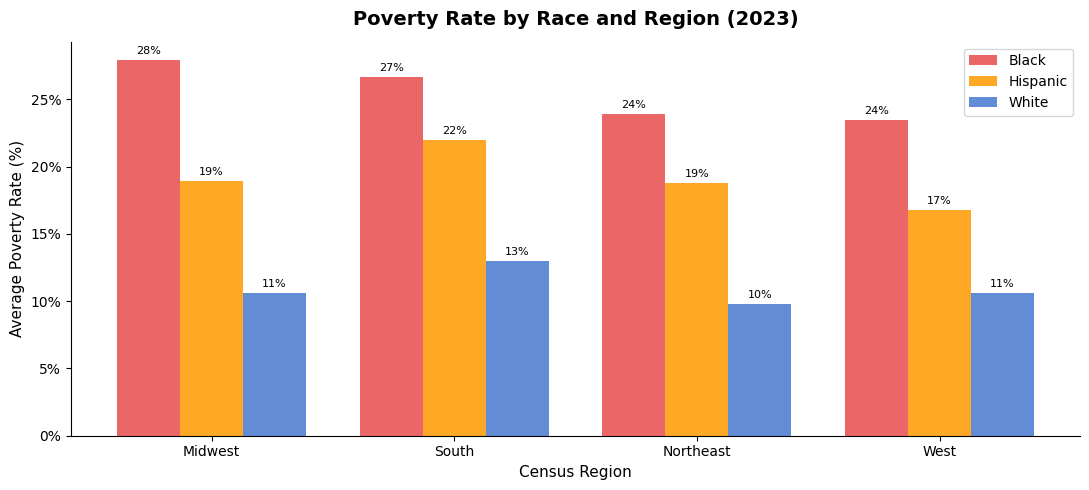


📊 What I notice: Black poverty rates are consistently the highest in every
single region. This is a structural pattern — not a regional anomaly.


In [17]:
racial = df.groupby('region')[['poverty_pct_black', 'poverty_pct_hispanic', 'poverty_pct_white']].mean().round(1)
racial = racial.sort_values('poverty_pct_black', ascending=False)

x = range(len(racial))
width = 0.26

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar([i - width for i in x], racial['poverty_pct_black'],   width, label='Black',    color='#E84B4B', alpha=0.85)
b2 = ax.bar([i          for i in x], racial['poverty_pct_hispanic'], width, label='Hispanic', color='#FF9900', alpha=0.85)
b3 = ax.bar([i + width  for i in x], racial['poverty_pct_white'],   width, label='White',    color='#4878CF', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if not pd.isna(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=8)

ax.set_title('Poverty Rate by Race and Region (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Census Region', fontsize=11)
ax.set_ylabel('Average Poverty Rate (%)', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(racial.index, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart4_racial_poverty_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 What I notice: Black poverty rates are consistently the highest in every")
print("single region. This is a structural pattern — not a regional anomaly.")


### Chart 5: Relationship: Poverty vs. Uninsured Rate
**Question:** Is there a relationship between poverty and lack of insurance at the county level?  
**Chart type:** Scatterplot — shows whether two numeric variables move together  
**What it shows:** How tightly poverty and uninsured rates are linked — and which regions drive the pattern

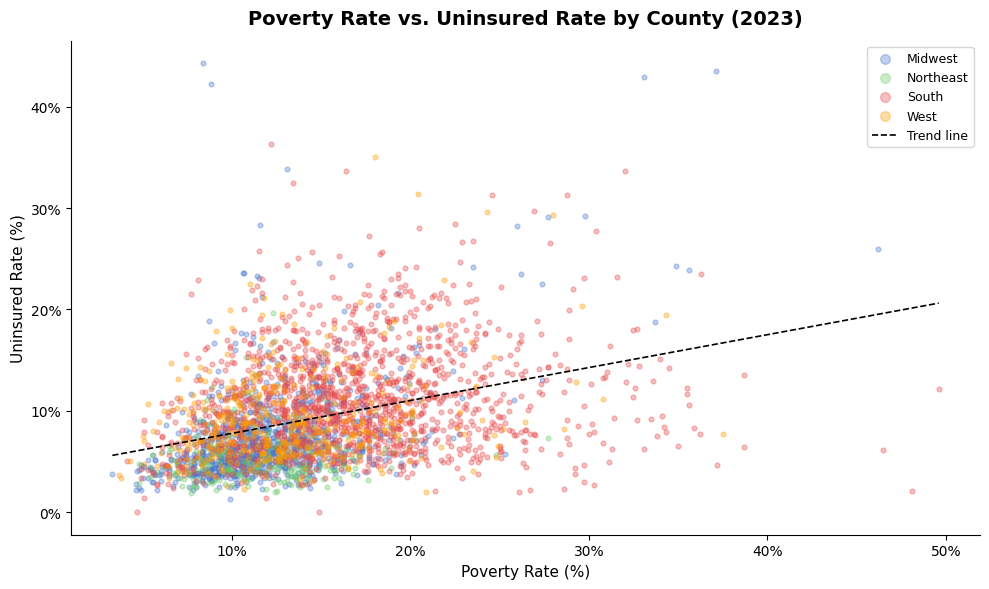


📊 Correlation coefficient: 0.361
Strong positive relationship — counties with higher poverty consistently
have higher uninsured rates. Southern counties cluster at the upper end.


In [18]:
region_colors = {'South': '#E84B4B', 'West': '#FF9900', 'Midwest': '#4878CF', 'Northeast': '#6ACC65'}

fig, ax = plt.subplots(figsize=(10, 6))

for region, grp in df.groupby('region'):
    ax.scatter(grp['poverty_pct'], grp['uninsured_pct'],
               label=region, alpha=0.35, s=12,
               color=region_colors.get(region, 'gray'))

# Add trend line
from numpy.polynomial.polynomial import polyfit
clean = df[['poverty_pct','uninsured_pct']].dropna()
b, m = polyfit(clean['poverty_pct'], clean['uninsured_pct'], 1)
x_line = [clean['poverty_pct'].min(), clean['poverty_pct'].max()]
y_line = [b + m * x for x in x_line]
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.2, label='Trend line')

ax.set_title('Poverty Rate vs. Uninsured Rate by County (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Poverty Rate (%)', fontsize=11)
ax.set_ylabel('Uninsured Rate (%)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.savefig('charts/chart5_poverty_vs_uninsured_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df[['poverty_pct','uninsured_pct']].corr().iloc[0,1]
print(f"\n📊 Correlation coefficient: {corr:.3f}")
print("Strong positive relationship — counties with higher poverty consistently")
print("have higher uninsured rates. Southern counties cluster at the upper end.")


### Chart 6 — Comparison: Top 15 Most Vulnerable States
**Question:** Which states have the highest average vulnerability scores?  
**Chart type:** Horizontal bar chart — ranks states clearly by a composite measure  
**What it shows:** Where the greatest concentration of SDOH hardship exists geographically

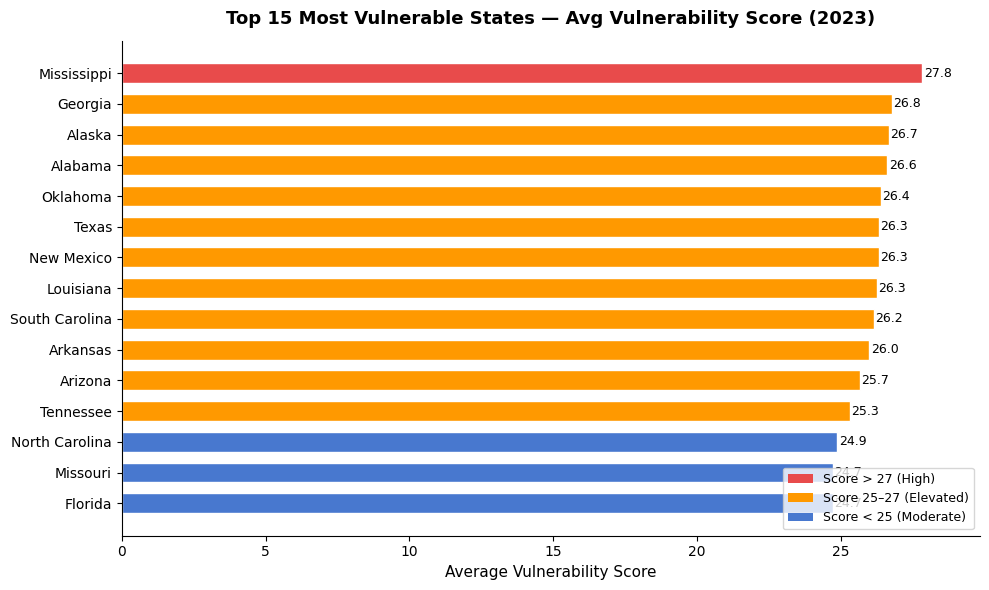


📊 What I notice: Mississippi, Louisiana, New Mexico, and West Virginia
consistently appear at the top — states where multiple SDOH factors
compound each other across nearly every county.


In [19]:
state_vuln = (df.groupby('state')['vulnerability_score']
                .mean()
                .sort_values(ascending=True)
                .tail(15))

fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['#E84B4B' if v > 27 else '#FF9900' if v > 25 else '#4878CF'
              for v in state_vuln.values]

bars = ax.barh(state_vuln.index, state_vuln.values,
               color=colors_bar, edgecolor='white', height=0.65)

for bar, val in zip(bars, state_vuln.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_title('Top 15 Most Vulnerable States — Avg Vulnerability Score (2023)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average Vulnerability Score', fontsize=11)
ax.set_xlim(0, state_vuln.max() + 2)

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E84B4B', label='Score > 27 (High)'),
    Patch(facecolor='#FF9900', label='Score 25–27 (Elevated)'),
    Patch(facecolor='#4878CF', label='Score < 25 (Moderate)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('charts/chart6_top_states_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 What I notice: Mississippi, Louisiana, New Mexico, and West Virginia")
print("consistently appear at the top — states where multiple SDOH factors")
print("compound each other across nearly every county.")


### Chart 7 — Relationship: Broadband Access vs. Poverty Rate
**Question:** Do poorer counties have less internet access — and what does that mean for telehealth?  
**Chart type:** Scatterplot — shows whether broadband gaps track with poverty  
**What it shows:** A critical access dimension — counties that are poorest are also least connected

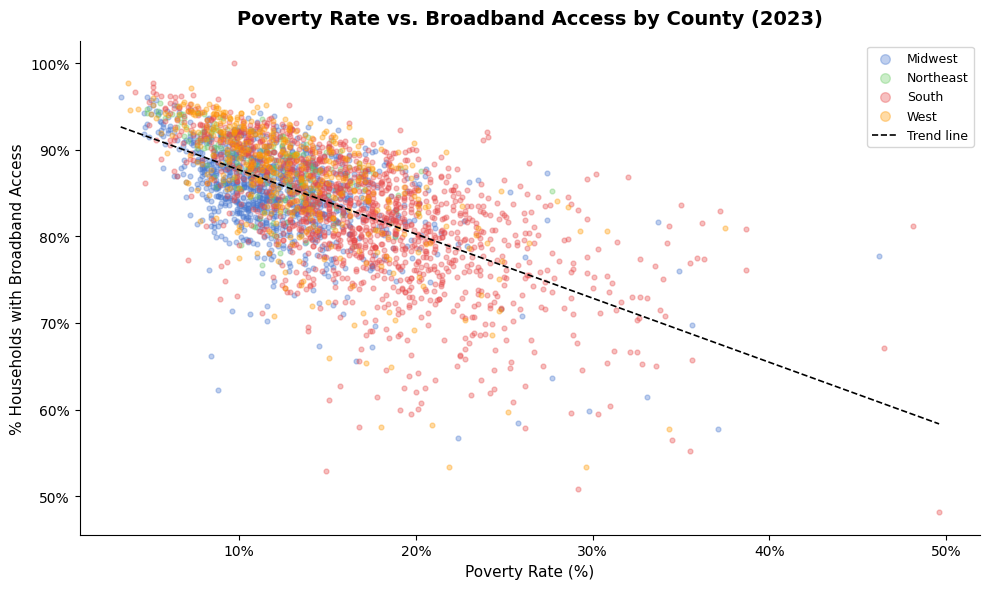


📊 Correlation: -0.626 (negative — as poverty rises, broadband drops)
This is critical for telehealth: the counties that most need remote healthcare
access are the same ones least able to use it.


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

for region, grp in df.groupby('region'):
    ax.scatter(grp['poverty_pct'], grp['broadband_pct'],
               label=region, alpha=0.35, s=12,
               color=region_colors.get(region, 'gray'))

# Trend line
clean2 = df[['poverty_pct','broadband_pct']].dropna()
b2, m2 = polyfit(clean2['poverty_pct'], clean2['broadband_pct'], 1)
x_line2 = [clean2['poverty_pct'].min(), clean2['poverty_pct'].max()]
y_line2 = [b2 + m2 * x for x in x_line2]
ax.plot(x_line2, y_line2, color='black', linestyle='--', linewidth=1.2, label='Trend line')

ax.set_title('Poverty Rate vs. Broadband Access by County (2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Poverty Rate (%)', fontsize=11)
ax.set_ylabel('% Households with Broadband Access', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.savefig('charts/chart7_broadband_vs_poverty.png', dpi=150, bbox_inches='tight')
plt.show()

corr2 = df[['poverty_pct','broadband_pct']].corr().iloc[0,1]
print(f"\n📊 Correlation: {corr2:.3f} (negative — as poverty rises, broadband drops)")
print("This is critical for telehealth: the counties that most need remote healthcare")
print("access are the same ones least able to use it.")


---
## Part 4 — Emerging Story Direction

### What surprised me
- **The broadband-poverty link** was stronger than expected — poorer counties are significantly
  less connected, which means they face barriers to telehealth exactly where it's needed most
- **Racial disparities** are not a Southern phenomenon — the Black-White poverty gap shows up in
  every region, including the Northeast and Midwest
- **Healthcare deserts** (>30 miles from ER) overlap heavily with both high poverty AND low broadband —
  a triple barrier for rural communities

### Gaps and limitations
- Distance to healthcare measures median distance, not whether people can actually access it
  (no transportation, no time off work, etc.)
- Racial poverty breakdowns have missing values for small counties where population counts are too low
- The vulnerability score is a simple average — some indicators may deserve more weight than others

### Trends worth digging into next
1. **Stacking disadvantages:** Can I identify counties that are poor AND uninsured AND lack broadband AND are far from an ER?
2. **State policy effects:** Do states that expanded Medicaid show lower uninsured rates even at similar poverty levels?
3. **Child poverty vs. adult poverty:** Are counties with high child poverty also the ones with the worst long-term outcomes?

### Questions guiding the final project
- *Which counties face the most compounded SDOH burden — and where are they?*
- *Is geographic isolation (distance to care) or socioeconomic hardship (poverty, uninsured) a stronger driver of vulnerability?*
- *What does this data say about where a company like Humana should target community health programs?*